In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

from IPython.core.display import display, HTML
display(HTML("<style>.output_scroll{height: auto !important;}</style>"))

In [3]:
df=pd.read_excel('Ti6Al4V-NiTi单道沉积试样实验观测缺陷类型数据汇总.xlsx',sheet_name='Sheet1')
sample_ids = df.iloc[:, 0].values
df

,试样标号,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,左润湿角（°）,右润湿角（°）,缺陷类型,熔合不良、气孔、球化=0_理想工艺=1_裂纹=2
0,A-1,0.0,600,200,1.000000,90.000000,2803.604,836.036,2075.6760,1762.162,131.315,99.836,熔合不良、气孔,0
1,A-2,0.0,700,200,1.000000,105.000000,3189.189,908.108,2428.8290,1751.351,109.671,91.650,气孔,0
2,A-3,0.0,800,200,1.000000,120.000000,3654.054,1001.802,2900.9010,1888.288,104.036,87.592,气孔,0
3,A-4,0.0,900,200,1.000000,135.000000,4075.676,1095.495,3189.1890,1780.180,92.068,98.973,气孔,0
4,A-5,0.0,600,250,0.600000,72.000000,2661.111,807.477,1824.0740,1659.259,138.094,134.676,气孔,0
5,A-6,0.0,700,250,0.600000,84.000000,3124.074,914.815,2301.8520,1648.148,132.679,112.818,气孔,0
6,A-7,0.0,800,250,0.600000,96.000000,3549.550,936.937,2724.3240,1517.117,99.851,85.486,气孔,0
7,A-8,0.0,900,250,0.600000,108.000000,3960.360,1045.045,3099.0990,1513.514,70.434,87.241,气孔,0
8,A-9,0.0,600,300,0.333333,60.000000,2631.776,798.131,2016.8220,1343.925,85.851,128.480,球化、气孔,0
9,A-10,0.0,700,300,0.333333,70.000000,3018.692,829.907,2366.3550,1338.486,96.607,81.174,气孔,0


In [4]:
df = df.drop(df.columns[[0, 12]], axis=1)
df

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,左润湿角（°）,右润湿角（°）,熔合不良、气孔、球化=0_理想工艺=1_裂纹=2
0,0.0,600,200,1.000000,90.000000,2803.604,836.036,2075.6760,1762.162,131.315,99.836,0
1,0.0,700,200,1.000000,105.000000,3189.189,908.108,2428.8290,1751.351,109.671,91.650,0
2,0.0,800,200,1.000000,120.000000,3654.054,1001.802,2900.9010,1888.288,104.036,87.592,0
3,0.0,900,200,1.000000,135.000000,4075.676,1095.495,3189.1890,1780.180,92.068,98.973,0
4,0.0,600,250,0.600000,72.000000,2661.111,807.477,1824.0740,1659.259,138.094,134.676,0
5,0.0,700,250,0.600000,84.000000,3124.074,914.815,2301.8520,1648.148,132.679,112.818,0
6,0.0,800,250,0.600000,96.000000,3549.550,936.937,2724.3240,1517.117,99.851,85.486,0
7,0.0,900,250,0.600000,108.000000,3960.360,1045.045,3099.0990,1513.514,70.434,87.241,0
8,0.0,600,300,0.333333,60.000000,2631.776,798.131,2016.8220,1343.925,85.851,128.480,0
9,0.0,700,300,0.333333,70.000000,3018.692,829.907,2366.3550,1338.486,96.607,81.174,0


In [5]:
value_counts = df.iloc[:, -1].value_counts()
print(value_counts)

熔合不良、气孔、球化=0_理想工艺=1_裂纹=2
0    46
2    41
1    33
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test, sample_ids_train, sample_ids_test = train_test_split(X, y, sample_ids, 
                                                                                       test_size=1./12, 
                                                                                       shuffle=True, 
                                                                                       random_state=10, 
                                                                                       stratify=y)

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import f1_score
from itertools import cycle
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier

TabPFN模型在测试集上的准确率： 0.9


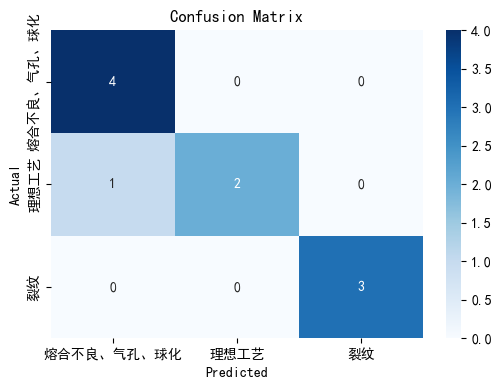

F1-Score: 0.8955555555555555
ROC_AUC: 0.9543650793650794


In [8]:
clf = TabPFNClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("TabPFN模型在测试集上的准确率：", accuracy_score(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'], yticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'])
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

f1 = f1_score(y_test, y_pred, average='weighted') 
print('F1-Score:', f1)
y_pred_prob = clf.predict_proba(X_test)
print("ROC_AUC:", roc_auc_score(y_test, y_pred_prob, multi_class='ovr'))

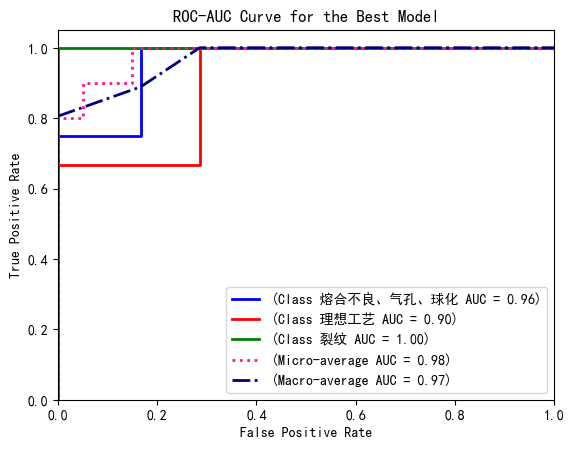

In [9]:
classes = ['熔合不良、气孔、球化', '理想工艺', '裂纹']
n_classes = len(classes)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve((y_test.to_numpy().reshape(-1, 1) == np.arange(n_classes)).ravel(),y_pred_prob.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr['macro'] = all_fpr
tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'(Class {classes[i]} AUC = {roc_auc[i]:.2f})')

plt.plot(fpr['micro'], tpr['micro'], color='deeppink', linestyle=':', linewidth=2, 
         label=f"(Micro-average AUC = {roc_auc['micro']:.2f})")

plt.plot(fpr['macro'], tpr['macro'], color='navy', linestyle='-.', linewidth=2,
         label=f"(Macro-average AUC = {roc_auc['macro']:.2f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for the Best Model')
plt.legend(loc='lower right')
plt.show()

INFO:tabpfn_extensions.post_hoc_ensembles.greedy_weighted_ensemble:Order of selections: [np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(0), np.int64(8), np.int64(1), np.int64(1), np.int64(1)]
INFO:tabpfn_extensions.post_hoc_ensembles.greedy_weighted_ensemble:Val loss over iterations: [np.float64(-0.819682893595937), np.float64(-0.8201148154046706), np.float64(-0.8223845799932757), np.float64(-0.8223845799932757), np.float64(-0.8223845799932757), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517), np.float64(-0.8234529560616517)

TabPFN_Post Hoc Ensembling模型在测试集上的准确率： 0.9


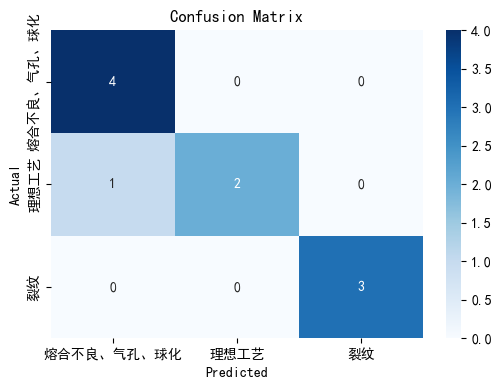

F1-Score: 0.8955555555555555
ROC_AUC: 0.9246031746031745


In [10]:
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier
classifier = AutoTabPFNClassifier(max_time=300, device="cuda") 
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
print("TabPFN_Post Hoc Ensembling模型在测试集上的准确率：", accuracy_score(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'], yticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'])
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

f1 = f1_score(y_test, y_pred, average='weighted') 
print('F1-Score:', f1)
y_pred_prob = classifier.predict_proba(X_test)
print("ROC_AUC:", roc_auc_score(y_test, y_pred_prob, multi_class='ovr'))

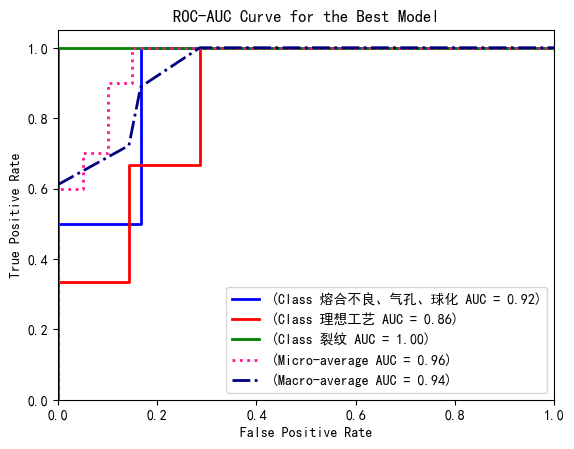

In [11]:
classes = ['熔合不良、气孔、球化', '理想工艺', '裂纹']
n_classes = len(classes)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve((y_test.to_numpy().reshape(-1, 1) == np.arange(n_classes)).ravel(),y_pred_prob.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr['macro'] = all_fpr
tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'(Class {classes[i]} AUC = {roc_auc[i]:.2f})')

plt.plot(fpr['micro'], tpr['micro'], color='deeppink', linestyle=':', linewidth=2, 
         label=f"(Micro-average AUC = {roc_auc['micro']:.2f})")

plt.plot(fpr['macro'], tpr['macro'], color='navy', linestyle='-.', linewidth=2,
         label=f"(Macro-average AUC = {roc_auc['macro']:.2f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for the Best Model')
plt.legend(loc='lower right')
plt.show()